# 01_回归算法-K近邻回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- KNN 的特征标准化放入 Pipeline，避免大尺度特征主导距离，并修复 pandas Series.data 接口。
- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿咱们聊聊K近邻回归\~

**K近邻回归（K-Nearest Neighbors Regression, KNN回归）**，简单又直观的机器学习方法，它用来预测数值型的数据（比如房价、气温等）。

基本原理：

1. **找邻居**：当我们想预测一个数据点的数值时，先在数据集中找到离它最近的 **K** 个点（邻居）。
2. **求平均值**：然后，把这 **K** 个邻居的数值（目标值）取平均，作为这个点的预测值。

举个例子：假设你想预测一个新房子的房价，而你手上有一堆已经卖出去的房子数据（包括它们的价格和地理位置）。K近邻回归的做法是：

- 找到 **K** 个离这个新房子最近的已售房子；
- 取这 **K** 个房子的平均价格，作为新房子的预测价格。

K值的影响：

- **K太小**（比如K=1）：预测结果会受到单个邻居的影响，可能不稳定。
- **K太大**（比如K=100）：虽然更稳定，但可能会包含太多远离目标的数据点，导致预测不够精准。
- **一般K值的选择**：需要通过实验（比如交叉验证）来找到一个合适的K。

## 原理详解

KNN 回归不依赖于训练数据的显式建模，而是通过找到新样本在训练数据中的**K个最近邻**，然后利用这些邻居的目标值来进行预测。

KNN回归的本质是**局部加权平均法**，是一种非参数估计方法。

### 1. 基本思想

给定一个训练数据集：


$$
D = \{(x_1, y_1), (x_2, y_2), ..., (x_N, y_N)\}
$$


其中：

$x_i \in \mathbb{R}^d$是输入特征向量

$y_i \in \mathbb{R}$是对应的目标值（输出）

$N$是训练数据集的大小

对于一个新的测试样本 $x^*$，KNN回归的基本思想是：

1. 在训练数据集中找到离 $x^*$最近的 **K个邻居**（按照某种距离度量）。
2. 根据这些邻居的目标值 $y$计算 $x^*$的预测值。

### 2. 距离度量

通常，KNN回归采用**欧氏距离**来度量样本之间的相似性：  

$d(x_i, x_j) = \sqrt{\sum_{m=1}^{d} (x_{im} - x_{jm})^2}$  

也可以使用其他距离度量，如：

- 曼哈顿距离：


$$
d(x_i, x_j) = \sum_{m=1}^{d} |x_{im} - x_{jm}|
$$


- 闵可夫斯基距离：

$d(x_i, x_j) = \left( \sum_{m=1}^{d} |x_{im} - x_{jm}|^p \right)^{\frac{1}{p}}$  

当 $p=2$时即为欧氏距离，当 $p=1$时即为曼哈顿距离。

### 3. 预测值计算

找到最近的 **K 个邻居** 后，KNN 回归的预测值可以通过**加权平均**的方法计算，常见的方法包括：

#### 1) 直接均值


$$
\hat{y}(x^*) = \frac{1}{K} \sum_{i=1}^{K} y_i
$$


其中，$y_i$是 $K$个最近邻的目标值。

#### 2) 距离加权均值

为了让更接近 $x^*$的样本具有更高的影响力，可以采用**加权平均**：


$$
\hat{y}(x^*) = \frac{\sum_{i=1}^{K} w_i y_i}{\sum_{i=1}^{K} w_i}
$$


权重 $w_i$通常与距离的倒数成正比，例如：


$$
w_i = \frac{1}{d(x^*, x_i) + \epsilon}
$$


其中 $\epsilon$是一个小的正数，防止分母为零。

#### 3) 高斯核加权

可以使用**核函数**（如高斯核）来赋予权重：


$$
w_i = \exp\left(-\frac{d(x^*, x_i)^2}{2\sigma^2}\right)
$$


这样，离测试点 $x^*$越近的点权重越大，影响力越强。

## 公式推理

### 1. KNN 回归的期望误差分析

KNN回归属于**非参数回归方法**，其误差可以从偏差-方差分解（Bias-Variance Decomposition）的角度分析。假设数据服从分布：


$$
y = f(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)
$$


其中 $f(x)$是真实函数，$\epsilon$是噪声。

KNN 回归的预测值：


$$
\hat{f}(x) = \frac{1}{K} \sum_{i=1}^{K} y_i
$$


对期望值取均值：


$$
\mathbb{E}[\hat{f}(x)] = \mathbb{E} \left[ \frac{1}{K} \sum_{i=1}^{K} f(x_i) \right]
$$


假设 $K$个最近邻均匀分布在 $x$附近：


$$
\mathbb{E}[\hat{f}(x)] \approx \frac{1}{K} \sum_{i=1}^{K} f(x_i) \approx f(x) + O\left(\frac{1}{K}\right)
$$


因此，KNN回归的偏差为：


$$
Bias(\hat{f}) = f(x) - \mathbb{E}[\hat{f}(x)] = O\left(\frac{1}{K}\right)
$$


方差计算：


$$
Var(\hat{f}) = \frac{\sigma^2}{K}
$$


总误差：


$$
Error = Bias^2 + Var = O\left(\frac{1}{K^2}\right) + O\left(\frac{1}{K}\right)
$$


因此，**当** $K$**过小时，方差较大（易过拟合）；当** $K$**过大时，偏差较大（易欠拟合）**。

## 算法流程

**输入**：

- 训练数据集 $D = \{(x_1, y_1), (x_2, y_2), ..., (x_N, y_N)\}$
- 需要预测的样本 $x^*$
- 选择邻居数 $K$
- 选择距离度量方式（如欧氏距离）
- 选择预测策略（均值、加权均值等）

**步骤**：

1. **计算距离**：计算测试样本 $x^*$与训练集中所有样本的距离：  
$d(x^*, x_i) = \sqrt{\sum_{m=1}^{d} (x_{im} - x^*_m)^2}$
2. **选择最近邻**：选取距离最近的 $K$个样本。
3. **计算预测值**：

   - 若采用均值方法：  
   $\hat{y}(x^*) = \frac{1}{K} \sum_{i=1}^{K} y_i$
   - 若采用加权方法：  
   $\hat{y}(x^*) = \frac{\sum_{i=1}^{K} w_i y_i}{\sum_{i=1}^{K} w_i}$
4. **输出预测结果** $\hat{y}(x^*)$。

## 完整案例

在这个案例中，我们先加载数据，然后用 KNN 进行回归预测，并利用 GridSearchCV 优化超参数（邻居数 k），最后通过多种可视化展示模型效果、预测值与真实值的对比、残差分布以及超参数调优过程的热力图。

数据集维度： (2500, 9)
数据集特征：
 Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


最优邻居数 k = 14
最佳均方误差 (MSE) = 0.45458756921584487
测试集均方误差 (MSE) = 0.42704022297301836
测试集 R2 score = 0.6602860059465947


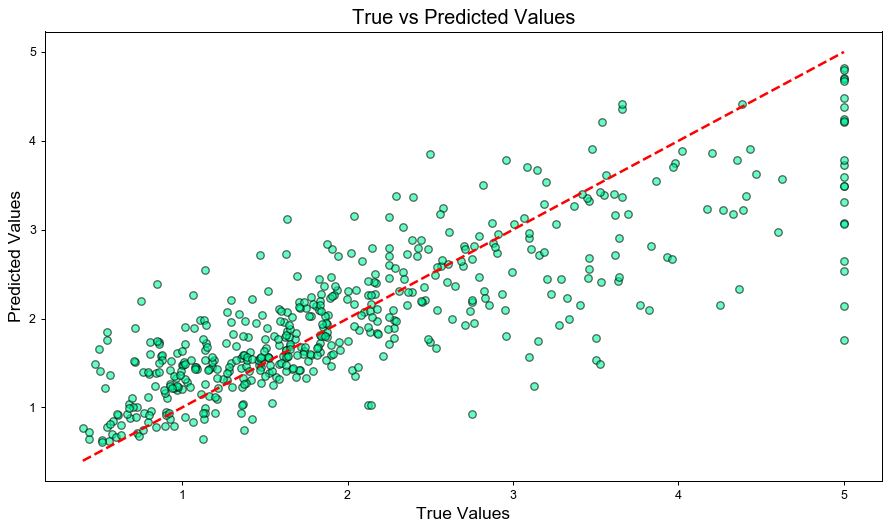

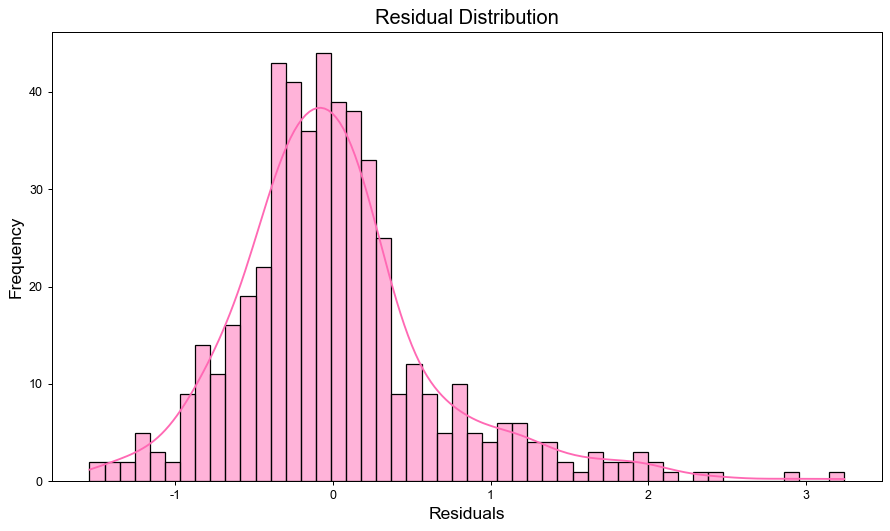

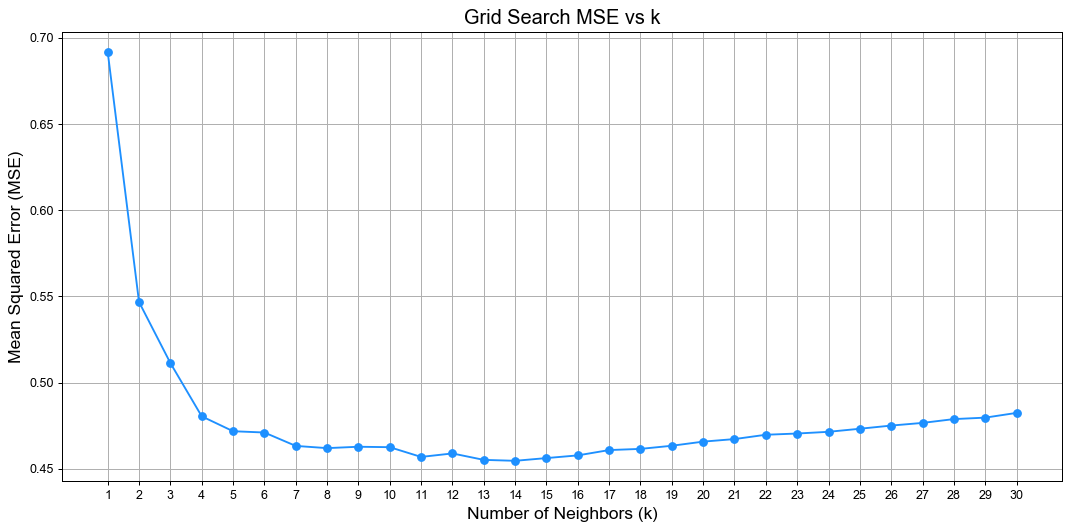

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from notebook_support import load_local_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score


# 加载 California 房价数据集
housing = load_local_housing(as_frame=True)
data = housing.frame
# 打印数据基本信息
print("数据集维度：", data.shape)
print("数据集特征：\n", data.columns)

# 选择特征与目标变量
X = data.drop("MedHouseVal", axis=1)  # 房屋中位数作为目标变量
y = data["MedHouseVal"]

# 将数据集拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 初始化 KNN 回归器
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
knn = make_pipeline(StandardScaler(), KNeighborsRegressor())

# 设置超参数搜索空间：邻居数从 1 到 30
param_grid = {'kneighborsregressor__n_neighbors': np.arange(1, 31)}

# 使用 GridSearchCV 进行超参数优化，采用 5 折交叉验证
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=1, error_score='raise')
grid_search.fit(X_train, y_train)

# 输出最优参数与对应的得分
best_k = grid_search.best_params_['kneighborsregressor__n_neighbors']
best_score = -grid_search.best_score_
print("最优邻居数 k =", best_k)
print("最佳均方误差 (MSE) =", best_score)

# 使用最优参数训练模型
best_knn = grid_search.best_estimator_
best_knn.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = best_knn.predict(X_test)

# 计算测试集上的 MSE 和 R2 分数
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("测试集均方误差 (MSE) =", mse)
print("测试集 R2 score =", r2)

# 可视化：真实值 vs 预测值
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='mediumspringgreen', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("True Values", fontsize=14)
plt.ylabel("Predicted Values", fontsize=14)
plt.title("True vs Predicted Values", fontsize=16)
plt.tight_layout()
plt.show()

# 可视化：残差分布
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True, color='hotpink')
plt.xlabel("Residuals", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Residual Distribution", fontsize=16)
plt.tight_layout()
plt.show()

# 可视化：GridSearchCV 中不同 k 值的均方误差热力图
# 提取所有搜索结果
results = pd.DataFrame(grid_search.cv_results_)
results['mean_test_mse'] = -results['mean_test_score']

plt.figure(figsize=(12, 6))
plt.plot(results['param_kneighborsregressor__n_neighbors'].to_numpy(), results['mean_test_mse'], marker='o', linestyle='-', color='dodgerblue')
plt.xlabel("Number of Neighbors (k)", fontsize=14)
plt.ylabel("Mean Squared Error (MSE)", fontsize=14)
plt.title("Grid Search MSE vs k", fontsize=16)
plt.xticks(results['param_kneighborsregressor__n_neighbors'].to_numpy())
plt.grid(True)
plt.tight_layout()
plt.show()

- **数据加载与预处理**：从 `load_local_housing` 加载数据，并将数据拆分为训练集与测试集，确保模型评估的客观性。
- **模型训练与超参数优化**：使用 `GridSearchCV` 对 KNN 回归器的邻居数进行调优，选取使均方误差最低的参数。
- **模型评估**：利用 MSE 与 R2 分数对模型进行评价，并通过散点图对比真实值与预测值，以及绘制残差分布图。

![原文参考图，当前结果见代码输出](attachments/img_021.png)

- **超参数调优可视化**：通过折线图展示不同邻居数对应的均方误差，直观展示模型的参数选择过程。

![原文参考图，当前结果见代码输出](attachments/img_022.png)

**算法优化说明：**

1. 采用 GridSearchCV 自动搜索最优的 k 值，并利用 5 折交叉验证提高模型泛化能力。
2. 对数据进行训练集和测试集的划分，确保模型在未知数据上的评估准确性。
3. 利用可视化手段直观展示模型效果及超参数选择结果，为进一步调参提供依据。

## 模型分析

### KNN回归 优缺点

**优点**：

1. **简单易懂，直观性强**：KNN 只需要计算距离，不涉及复杂的数学建模，非常容易理解和实现。
2. **非参数方法**：KNN 不需要对数据分布做假设，适用于各种数据类型，尤其是非线性数据。
3. **适用于小数据集**：在小规模数据上表现较好，不需要大量训练时间，适用于数据量较少但维度较高的场景。
4. **适用于局部模式学习**：对于局部模式明显的数据，KNN 可以很好地拟合，例如地理位置相关的数据预测。

**缺点**：

1. **计算量大，预测速度慢**：KNN 需要存储所有训练数据，并在预测时计算每个样本到所有训练样本的距离，计算开销较大，特别是在大数据集上表现较差。
2. **受维度灾难影响**：高维数据会导致欧几里得距离的效果变差，样本点之间的距离趋于相等，使得 KNN 变得无效。
3. **对噪声敏感**：KNN 依赖于距离度量，如果数据中存在异常值或噪声点，可能会显著影响预测结果。
4. **无法输出概率**：不像一些统计学习方法（如贝叶斯回归）能给出置信度，KNN 仅能提供一个具体的预测值，缺乏不确定性度量。

### KNN 回归与其他相似算法的对比

| 算法 | 适用场景 | 优点 | 缺点 |
|-|-|-|-|
| **KNN 回归** | 适用于小数据集、非线性数据、局部模式学习 | 易理解、非参数、适应性强 | 计算量大、对高维数据效果差、对噪声敏感 |
| **线性回归** | 适用于线性关系的数据 | 计算效率高、可解释性强 | 仅适用于线性数据，对非线性数据拟合较差 |
| **决策树回归** | 适用于数据集较大、有明显分段特征的数据 | 能处理非线性数据、不需要标准化 | 易过拟合、对噪声敏感 |
| **随机森林回归** | 适用于大规模数据、有较多特征的数据 | 处理非线性关系能力强、不易过拟合 | 计算复杂度较高 |
| **支持向量回归 (SVR)** | 适用于小规模、高维数据集 | 适用于高维数据、支持核方法 | 计算复杂度较高、对超参数敏感 |
| **神经网络回归** | 适用于大数据、高度非线性关系的数据 | 适用于复杂任务、强大的表达能力 | 训练时间长、需要大量数据、难以解释 |

### 在什么情况下优选 KNN，什么时候应该考虑其他算法？

**适合使用 KNN 的情况**：

- 数据集较小，计算量可接受（如 <10,000 条样本）。
- 需要处理非线性数据，且数据分布未知时，KNN 可作为基准模型。
- 数据具有局部模式，例如地理位置预测、推荐系统等。
- 需要快速实现一个基准模型进行对比。

**应考虑其他算法的情况**：

- **数据量大（> 10 万条）**：KNN 计算所有样本距离的过程过慢，推荐使用**决策树回归**或**随机森林**。
- **数据是高维（> 50 维）**：KNN 受维度灾难影响较大，推荐**支持向量回归 (SVR)** 或 **神经网络**。
- **数据有线性趋势**：如果数据关系接近线性，使用**线性回归**的计算效率更高。
- **需要解释性和可解释的决策规则**：KNN 不易解释，推荐使用**决策树回归**或**线性回归**。
- **数据包含较多噪声**：KNN 对噪声敏感，推荐使用**随机森林回归**，因其鲁棒性较强。

### 总结

KNN 回归是一种直观、易于实现的算法，适用于小规模、非线性数据集。但在大数据、高维场景或计算效率要求高的应用中，KNN 可能不是最佳选择，此时可以考虑决策树、随机森林、支持向量机等替代方案。